# IBEX 35 Volatility: Stage 3 — The GARCH Family

Stage 2 established the key empirical fact this whole project is built on: daily
IBEX 35 and S&P 500 returns are close to uncorrelated in the mean, but their
*squared* residuals are strongly autocorrelated — variance is predictable even
when the return itself is not. This notebook is where we actually model that
variance.

We fit and compare three members of the GARCH family — GARCH(1,1), GJR-GARCH,
and EGARCH — using the [`arch`](https://arch.readthedocs.io/) package. All three
share the same mean specification and error distribution so that differences
in fit are attributable to the *variance* specification alone, which is the
thing we're actually comparing.

This notebook is self-contained: it re-downloads the same ~10y of daily data
used in Stages 1-2.

**Goals of this notebook**
1. Fit GARCH(1,1), GJR-GARCH(1,1,1) and EGARCH(1,1) to both indices.
2. Interpret every parameter economically — persistence, the leverage effect,
   and tail thickness.
3. Select a preferred model per index and confirm with residual diagnostics
   that it has actually absorbed the volatility clustering.
4. Plot the resulting conditional volatility and mark the COVID-19 shock.


## 1. Setup

In [1]:
import sys
import warnings

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns
from arch import arch_model
from scipy import stats
from statsmodels.stats.diagnostic import het_arch

# We deliberately do not blanket-silence warnings: convergence/numerical
# warnings from the arch optimizer are informative and should surface. We
# only filter one specific, known-benign message: a yfinance-internal pandas
# deprecation notice unrelated to result validity.
warnings.filterwarnings("ignore", message="Timestamp.utcnow is deprecated.*")

sys.path.insert(0, "..")
from src.utils import download_data

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100


## 2. Data

Same construction as Stages 1-2: ~10 years of daily closes for the IBEX 35
(`^IBEX`) and S&P 500 (`^GSPC`), adjusted for splits/dividends. This time we
scale log returns to **percent**, $100 \times \ln(P_t / P_{t-1})$, rather than
raw decimal log returns. The economics are identical — it's a linear rescaling
— but GARCH is fit by numerical maximum likelihood, and decimal daily returns
are so small ($\sigma \approx 0.01$) that $\omega$ and the squared-shock terms
become tiny, flat-gradient numbers that make the optimizer struggle to
converge. Working in percent keeps all parameters on a well-conditioned scale.


In [2]:
_, returns_pct = download_data()
returns_pct.describe()


Ticker,SP500,IBEX35
count,2486.000000,2486.000000
mean,0.051145,0.034452
std,1.143229,1.153680
min,-12.765220,-15.151176
25%,-0.374437,-0.526779
50%,0.080364,0.062811
75%,0.580441,0.640569
max,9.089488,8.225265


## 3. GARCH(1,1) — the baseline

The workhorse volatility model. Conditional variance follows

$$
\sigma_t^2 = \omega + \alpha\, \varepsilon_{t-1}^2 + \beta\, \sigma_{t-1}^2
$$

- $\omega > 0$: a baseline/floor variance level — what variance would revert
  to in the very long run, absent new shocks.
- $\alpha$ (**ARCH term**): how much *yesterday's squared surprise*
  $\varepsilon_{t-1}^2$ feeds into today's variance — the "reactiveness" of
  volatility to fresh news.
- $\beta$ (**GARCH term**): how much of *yesterday's variance* carries over —
  the "memory" or persistence of volatility.

The sum $\alpha + \beta$ is the **persistence** of the process: it governs how
quickly a volatility shock decays back toward its long-run level. Values close
to 1 mean shocks decay very slowly (volatility is highly persistent, and
today's turbulence is a good predictor of next week's); values further from 1
mean variance mean-reverts quickly.

For the mean equation, we use a **constant mean** (rather than the small ARIMA
orders from Stage 2) across all three models: Stage 2 showed the ARIMA
structure, while statistically detectable, is economically negligible, and
keeping the mean equation fixed and simple isolates the *variance*
specification as the only thing that differs across the three models we're
comparing. Innovations are modelled as **Student-t** — motivated directly by
the heavy tails found in Stage 1 — so the model itself estimates how fat the
tails are via the degrees-of-freedom parameter $\nu$, rather than assuming
Gaussian shocks.


In [3]:
results = {}

for idx in returns_pct.columns:
    am = arch_model(returns_pct[idx], mean="Constant", vol="GARCH", p=1, q=1, dist="t")
    results[(idx, "GARCH")] = am.fit(disp="off")

for idx in returns_pct.columns:
    print(f"\n=== {idx} — GARCH(1,1) ===")
    print(results[(idx, "GARCH")].summary())



=== SP500 — GARCH(1,1) ===
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                        SP500   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -3104.28
Distribution:      Standardized Student's t   AIC:                           6218.56
Method:                  Maximum Likelihood   BIC:                           6247.65
                                              No. Observations:                 2486
Date:                      Fri, Jul 17 2026   Df Residuals:                     2485
Time:                              02:12:30   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
---------------------------------------------------------

**Interpretation.** Both indices show highly significant $\alpha$ and $\beta$
(p < 0.001). For the **S&P 500**: $\alpha \approx 0.157$, $\beta \approx
0.842$, and persistence $\alpha+\beta \approx 0.999$ — essentially at the
unit-root boundary (an *integrated* GARCH, or IGARCH-like result), meaning a
volatility shock would barely decay at all under this specification. For the
**IBEX 35**: $\alpha \approx 0.138$, $\beta \approx 0.779$, persistence
$\approx 0.92$ — high, but comfortably below 1. As we'll see in Section 7,
the S&P's near-unit persistence here is itself informative: it's a symptom of
forcing a *symmetric* model onto a market with a strong leverage effect (the
model has nowhere else to put the extra variance clustering caused by bad
news except into $\beta$), and it resolves once asymmetry is allowed in
GJR-GARCH/EGARCH. The Student-t $\nu$ is $\approx 5.1$ (S&P) and $\approx
7.1$ (IBEX) — both comfortably in the empirical 3-8 range, confirming fat
tails remain in the standardized residuals even after modelling
time-varying variance (more on this in Section 8).


## 4. GJR-GARCH(1,1,1) — the leverage effect

Plain GARCH treats a positive and a negative shock of the same size as equally
informative about future variance. Empirically, that's false for equities: bad
news raises volatility more than good news of the same magnitude — the
**leverage effect** (named for the mechanical story that a stock price drop
raises a firm's debt-to-equity ratio, though the effect is also explained by
volatility feedback / risk-aversion channels). Glosten-Jagannathan-Runkle
(GJR) GARCH captures this with an asymmetry term:

$$
\sigma_t^2 = \omega + \alpha\, \varepsilon_{t-1}^2 + \gamma\, I[\varepsilon_{t-1}<0]\, \varepsilon_{t-1}^2 + \beta\, \sigma_{t-1}^2
$$

where $I[\varepsilon_{t-1}<0]$ is an indicator equal to 1 when yesterday's
shock was negative and 0 otherwise. A **positive shock** feeds through with
weight $\alpha$; a **negative shock** of the same size feeds through with
weight $\alpha + \gamma$. So:

- $\gamma > 0$ and statistically significant → negative shocks raise variance
  more than positive ones → **leverage effect present**.
- $\gamma \approx 0$ → shocks are symmetric, no leverage effect.

Because the indicator is "on" only for roughly half of all shocks, the
persistence of a GJR-GARCH process is $\alpha + \beta + \gamma/2$ (the average
effective ARCH weight across positive and negative shocks), which we'll use
for a like-for-like comparison with plain GARCH. **That $\gamma/2$ specifically
assumes a symmetric innovation distribution**, i.e. $P(\varepsilon_{t-1}<0) =
0.5$ — true here, since the (unskewed) Student-t we fit throughout this
notebook is symmetric around zero. Stage 5 (Section 15) fits exactly this skewed distribution — skew-t, with
$\lambda \approx -0.116$ (IBEX 35) and $-0.184$ (S&P 500), both significant
at p < 0.001 — confirming the negative skewness Stage 1 found in both
indices carries into the innovations. That makes this caveat live, not
theoretical: under Stage 5's skew-t fits, $P(\varepsilon_{t-1}<0) \neq 0.5$,
so this formula's $\gamma/2$ would need replacing with
$\gamma \cdot P(\varepsilon_{t-1}<0)$ under that distribution — the
$\alpha+\beta+\gamma/2$ persistence figures used throughout Stages 3-5 are
specific to the symmetric-Student-t specification, not a general property
of the fitted GJR-GARCH process.


In [4]:
for idx in returns_pct.columns:
    am = arch_model(returns_pct[idx], mean="Constant", vol="GARCH", p=1, o=1, q=1, dist="t")
    results[(idx, "GJR-GARCH")] = am.fit(disp="off")

for idx in returns_pct.columns:
    print(f"\n=== {idx} — GJR-GARCH(1,1,1) ===")
    print(results[(idx, "GJR-GARCH")].summary())



=== SP500 — GJR-GARCH(1,1,1) ===
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                        SP500   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -3067.77
Distribution:      Standardized Student's t   AIC:                           6147.54
Method:                  Maximum Likelihood   BIC:                           6182.45
                                              No. Observations:                 2486
Date:                      Fri, Jul 17 2026   Df Residuals:                     2485
Time:                              02:12:30   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
---------------------------------------------------

                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                       IBEX35   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -3457.03
Distribution:      Standardized Student's t   AIC:                           6926.07
Method:                  Maximum Likelihood   BIC:                           6960.98
                                              No. Observations:                 2486
Date:                      Fri, Jul 17 2026   Df Residuals:                     2485
Time:                              02:12:30   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

**Interpretation.** For both indices $\gamma$ is positive and highly
significant: $\gamma \approx 0.233$ (p < 0.001) for the S&P 500 and
$\gamma \approx 0.189$ (p < 0.001) for the IBEX 35 — clear evidence of a
**leverage effect** in both markets (confirmed cross-market comparison in
Section 7). More striking: once $\gamma$ absorbs the asymmetric response, the
*symmetric* ARCH term $\alpha$ becomes small and statistically indistinguishable
from zero for the S&P 500 ($\alpha \approx 0.006$, p = 0.67) and only
borderline significant for the IBEX 35 ($\alpha \approx 0.026$, p = 0.049 —
just under the conventional 5% threshold, not a robust finding on its own).
In other words, almost all of daily variance's reactivity to "yesterday's
surprise" is coming through the *bad-news* channel specifically — a
same-sized positive shock barely moves tomorrow's variance at all. This also
resolves the near-unit-persistence puzzle from Section 3: the effective
persistence here, $\alpha+\beta+\gamma/2$, drops to $\approx 0.981$ (S&P) and
$\approx 0.915$ (IBEX) — plain GARCH was overstating persistence by
misattributing an asymmetry effect to pure memory.


## 5. EGARCH(1,1) — asymmetry in log-variance

EGARCH (Nelson, 1991) models the *log* of conditional variance instead of the
variance itself:

$$
\ln(\sigma_t^2) = \omega + \beta \ln(\sigma_{t-1}^2) + \alpha\left[\, |z_{t-1}| - E|z_{t-1}|\, \right] + \gamma\, z_{t-1}
$$

where $z_{t-1} = \varepsilon_{t-1}/\sigma_{t-1}$ is the standardized shock.
Two practical advantages over GARCH/GJR-GARCH:

- Because it models $\ln(\sigma_t^2)$, the fitted variance $\sigma_t^2 =
  \exp(\cdot)$ is **automatically positive** for any parameter values — no
  non-negativity constraints needed on $\omega, \alpha, \beta$.
- Asymmetry is captured directly by $\gamma$ on the *signed* standardized
  shock $z_{t-1}$ (not an indicator-switched squared term): a **negative**
  $\gamma$ means a negative shock ($z_{t-1}<0$) pushes log-variance up by more
  than a same-sized positive shock pushes it down — the EGARCH expression of
  the same leverage effect GJR-GARCH captures with a positive $\gamma$. The
  $\alpha$ term is the pure magnitude ("size of surprise") effect, symmetric
  by construction, while $\gamma$ is the sign ("good news vs. bad news")
  effect layered on top.

Persistence in EGARCH is governed by $\beta$ alone (it is the AR coefficient
of an AR(1) process in log-variance), so it isn't directly comparable to the
$\alpha+\beta$ sum from GARCH/GJR-GARCH on the same numeric scale — we report
it separately in the comparison table.


In [5]:
for idx in returns_pct.columns:
    am = arch_model(returns_pct[idx], mean="Constant", vol="EGARCH", p=1, o=1, q=1, dist="t")
    results[(idx, "EGARCH")] = am.fit(disp="off")

for idx in returns_pct.columns:
    print(f"\n=== {idx} — EGARCH(1,1) ===")
    print(results[(idx, "EGARCH")].summary())



=== SP500 — EGARCH(1,1) ===


                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                        SP500   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -3058.49
Distribution:      Standardized Student's t   AIC:                           6128.98
Method:                  Maximum Likelihood   BIC:                           6163.89
                                              No. Observations:                 2486
Date:                      Fri, Jul 17 2026   Df Residuals:                     2485
Time:                              02:12:31   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                       IBEX35   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -3462.74
Distribution:      Standardized Student's t   AIC:                           6937.47
Method:                  Maximum Likelihood   BIC:                           6972.38
                                              No. Observations:                 2486
Date:                      Fri, Jul 17 2026   Df Residuals:                     2485
Time:                              02:12:31   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

**Interpretation.** EGARCH's $\gamma$ comes out negative and highly
significant for both indices — $\gamma \approx -0.167$ (p < 0.001) for the
S&P 500 and $\gamma \approx -0.127$ (p < 0.001) for the IBEX 35 — which is
exactly the EGARCH-side confirmation of the GJR-GARCH finding: negative
shocks push (log-)variance up by more than positive shocks push it down, in
both markets, with the effect again larger for the S&P 500. Persistence via
$\beta$ is $\approx 0.974$ (S&P) and $\approx 0.932$ (IBEX) — both high but,
like GJR-GARCH, below plain GARCH's near-unit-root S&P estimate. By AIC/BIC
(Section 6/9), EGARCH turns out to be the best-fitting specification for the
S&P 500, and a close second to GJR-GARCH for the IBEX 35.


## 6. Model comparison

We collect $\omega, \alpha, \gamma, \beta, \nu$ (Student-t degrees of freedom),
persistence, log-likelihood, AIC and BIC for all six fits (3 models × 2
indices) into one table. Lower AIC/BIC indicates a better fit net of
complexity; for nested-ish comparisons like these (GARCH is a restricted case
of GJR-GARCH with $\gamma=0$) it is the standard way to judge whether the
extra asymmetry parameter earns its keep.


In [6]:
def persistence(params, model):
    if model == "GARCH":
        return params["alpha[1]"] + params["beta[1]"]
    if model == "GJR-GARCH":
        # gamma/2 assumes a symmetric innovation distribution (P(eps<0)=0.5,
        # true for the unskewed Student-t used here). A skewed distribution
        # would need gamma * P(eps<0) under that distribution instead.
        return params["alpha[1]"] + params["beta[1]"] + params["gamma[1]"] / 2
    if model == "EGARCH":
        return params["beta[1]"]
    raise ValueError(model)


rows = []
for (idx, model), res in results.items():
    p = res.params
    rows.append({
        "Index": idx,
        "Model": model,
        "omega": p.get("omega"),
        "alpha": p.get("alpha[1]"),
        "gamma": p.get("gamma[1]", np.nan),
        "beta": p.get("beta[1]"),
        "nu": p.get("nu"),
        "Persistence": persistence(p, model),
        "LogLik": res.loglikelihood,
        "AIC": res.aic,
        "BIC": res.bic,
    })

comparison_df = pd.DataFrame(rows).set_index(["Index", "Model"]).sort_index()
comparison_df.round(4)


omega   alpha   gamma    beta      nu  Persistence  \
Index  Model                                                            
IBEX35 EGARCH     0.0028  0.2023 -0.1267  0.9323  7.5924       0.9323   
       GARCH      0.0938  0.1376     NaN  0.7793  7.1049       0.9169   
       GJR-GARCH  0.0902  0.0261  0.1890  0.7943  7.6045       0.9150   
SP500  EGARCH    -0.0044  0.1809 -0.1665  0.9742  5.5277       0.9742   
       GARCH      0.0178  0.1568     NaN  0.8422  5.1340       0.9991   
       GJR-GARCH  0.0210  0.0063  0.2330  0.8586  5.4396       0.9814   

                     LogLik        AIC        BIC  
Index  Model                                       
IBEX35 EGARCH    -3462.7359  6937.4717  6972.3823  
       GARCH     -3479.9773  6969.9546  6999.0468  
       GJR-GARCH -3457.0336  6926.0672  6960.9778  
SP500  EGARCH    -3058.4890  6128.9780  6163.8886  
       GARCH     -3104.2778  6218.5556  6247.6477  
       GJR-GARCH -3067.7718  6147.5435  6182.4541

**Interpretation.** Two patterns are immediately visible in the table. First,
**allowing asymmetry always improves the fit materially**: for both indices,
GJR-GARCH and EGARCH beat plain GARCH by a wide AIC/BIC margin (e.g. S&P 500
AIC falls from 6219 under GARCH to 6148 under GJR-GARCH and 6129 under
EGARCH) — a single extra asymmetry parameter earns a large improvement in
likelihood, which is itself evidence that the leverage effect is a real,
important feature of the data rather than statistical noise. Second, **which
asymmetric model wins differs by index**: EGARCH has the lowest AIC/BIC for
the S&P 500, while GJR-GARCH has the lowest AIC/BIC for the IBEX 35 (though
EGARCH is close behind, 6937 vs. 6926). Neither dominates universally, which
is fairly typical in the literature — the two encode leverage differently
(multiplicative squared-shock switch vs. additive log-variance shift) and
can rank differently across return series with different tail/asymmetry
combinations. We carry the per-index AIC winner forward as the preferred
model in Section 9.


## 7. The leverage effect, across markets

Our first headline cross-market question: **is the leverage effect present in
both indices, and is it stronger in one than the other?** We read this off the
$\gamma$ estimate (and its significance) in both the GJR-GARCH and EGARCH
fits, since agreement between two differently-specified models is stronger
evidence than either alone.


In [7]:
leverage_rows = []
for idx in returns_pct.columns:
    gjr = results[(idx, "GJR-GARCH")]
    egarch = results[(idx, "EGARCH")]
    leverage_rows.append({
        "Index": idx,
        "GJR gamma": gjr.params["gamma[1]"],
        "GJR gamma p-value": gjr.pvalues["gamma[1]"],
        "EGARCH gamma": egarch.params["gamma[1]"],
        "EGARCH gamma p-value": egarch.pvalues["gamma[1]"],
    })

leverage_df = pd.DataFrame(leverage_rows).set_index("Index")
leverage_df.round(4)


,GJR gamma,GJR gamma p-value,EGARCH gamma,EGARCH gamma p-value
Index,,,,
SP500,0.233,0.0,-0.1665,0.0
IBEX35,0.189,0.0,-0.1267,0.0


**Interpretation.** Both models agree, for both indices, that the leverage
effect is real: GJR $\gamma$ is positive and EGARCH $\gamma$ is negative,
each significant at p < 0.001 across the board — **within** each market,
this is not in question. The point estimates also point the same direction
in both specifications: GJR $\gamma \approx 0.233$ (S&P) vs. $0.189$
(IBEX), EGARCH $\gamma \approx -0.167$ (S&P) vs. $-0.127$ (IBEX).

We flag, rather than assert, the cross-market comparison this invites.
Consistency across two specifications fit to the same data is a weak
argument for "the S&P's leverage effect is stronger": both models see the
same sampling noise, so agreement between them doesn't rule out that noise
being the whole story. Section 12 tests the gap formally and finds it is
**not** statistically distinguishable from zero at conventional levels
($p=0.43$ for GJR, $p=0.12$ for EGARCH, and a block bootstrap that doesn't
assume the two markets are independent agrees, $p=0.15$), despite the
same-direction point estimates. The economic story sometimes offered for a
larger US asymmetry — a bigger options/derivatives base and
volatility-targeting flows, channels beyond the classical debt-to-equity
mechanism — remains a plausible *ex ante* hypothesis for why US large-cap
volatility might react more sharply to bad news, but this notebook's own
data cannot be said to confirm it.

## 8. Fat tails — the Student-t degrees of freedom

The second headline cross-market question: **how fat are the tails, and does
that differ by market?** The Student-t distribution nests the normal as
$\nu \to \infty$; low $\nu$ means much more mass in the tails than a normal
distribution assigns. Equity-index GARCH fits typically estimate $\nu$
somewhere in the **3-8** range — confirming, model-internally, the same heavy
tails Stage 1's Jarque-Bera test flagged in the raw, unconditional return
distribution. Note this $\nu$ describes the tails of the *standardized*
shocks $z_t = \varepsilon_t/\sigma_t$ left over **after** GARCH has already
absorbed the time-varying variance — so it captures genuine "excess" tail risk
that volatility clustering alone doesn't explain.


In [8]:
nu_df = comparison_df["nu"].unstack("Model")
nu_df.round(2)


Model,EGARCH,GARCH,GJR-GARCH
Index,,,
IBEX35,7.59,7.10,7.60
SP500,5.53,5.13,5.44


**Interpretation.** $\nu$ is fairly stable across the three model
specifications for a given index (as expected — it mainly reflects the
return series' own tail behavior, not the variance equation chosen): roughly
**5.1-5.5 for the S&P 500** and **7.1-7.6 for the IBEX 35**. Both are
comfortably inside the 3-8 range typical of equity indices and both confirm
genuine excess kurtosis survives *after* GARCH has already absorbed the
time-varying variance — the raw heavy tails from Stage 1 are not fully
explained by volatility clustering alone.

The cross-market gap — the S&P 500's point estimate is lower (fatter tails)
than the IBEX 35's — is directionally interesting but, per Section 12's
formal test, not cleanly established: a $z$-test does not distinguish it
from zero ($p=0.11$), while a block bootstrap that doesn't assume the two
markets are independent does ($p=0.006$). The two methods disagree, and we
treat this as suggestive evidence, not a settled finding — see Section 12
for the full discussion of why they disagree. We also no longer cite
"consistent with Section 7's stronger leverage effect" as supporting
evidence for this, as an earlier version of this notebook did: that
leverage comparison is itself not statistically significant (Section 12),
so it cannot lend support to a different, separately unproven comparison.

## 9. Model selection and residual diagnostics

We select the preferred model per index as the one with the lowest AIC among
the three fitted specifications (BIC, which penalizes extra parameters more
heavily, is reported alongside as a cross-check). **This selection is
deliberately scoped to the variance equation only**: the innovation
distribution is held fixed at symmetric Student-t throughout, so GARCH,
GJR-GARCH and EGARCH are compared on equal distributional footing. The
distribution itself is a separate design choice, tested as a robustness
check in Stage 5 (Section 15), where a skew-t innovation distribution is
shown to lower AIC further for both indices' preferred variance
specifications (S&P 500 EGARCH: 6128.98 → 6092.11; IBEX 35 GJR-GARCH:
6926.07 → 6911.84) — "AIC-selected" here should be read as selected over
the variance equation, not the full model space. The real test of whether a
volatility model "worked," though, isn't the information criterion — it's
whether its **standardized residuals**, $z_t = \varepsilon_t / \sigma_t$, have
been cleaned of the ARCH effect that motivated this whole notebook. We re-run
the same Engle ARCH-LM test from Stage 2, but this time on $z_t$ instead of
raw returns: if the volatility model did its job, this test should now
**fail to reject** the null of no remaining ARCH effect.

Alongside that, we formally test the assumption every VaR figure in this
project ultimately rests on: that $z_t$ actually follows a Student-t
distribution. The QQ plots in Stage 4 give visual evidence for this, but a
visual check is not a test — the standardized-t quantile *is* the VaR
formula, so if the distributional assumption is wrong, every downstream
risk number inherits that error. We test it here with a **Kolmogorov-Smirnov**
goodness-of-fit test against the variance-standardized Student-t (i.e. $t(\nu)$
scaled by $\sqrt{(\nu-2)/\nu}$ — the same unit-variance convention
`std_t_quantile` uses, not the raw, non-unit-variance $t(\nu)$).

In [9]:
def std_t_cdf(x, nu):
    """CDF of the variance-standardized (unit-variance) Student-t -- the same
    scaling convention as src.utils.std_t_quantile, so this tests the exact
    distribution the VaR formulas elsewhere in this project actually use."""
    c = np.sqrt((nu - 2) / nu)
    return stats.t.cdf(x / c, df=nu)


preferred = {}
for idx in returns_pct.columns:
    aic_by_model = comparison_df.loc[idx, "AIC"]
    preferred[idx] = aic_by_model.idxmin()

diag_rows = []
for idx, model in preferred.items():
    res = results[(idx, model)]
    std_resid = res.std_resid.dropna()
    nu_hat = res.params["nu"]

    lm_stat, lm_pvalue, _, _ = het_arch(std_resid, nlags=10)
    ks_result = stats.kstest(std_resid, lambda x: std_t_cdf(x, nu_hat))

    diag_rows.append({
        "Index": idx,
        "Preferred model": model,
        "AIC": res.aic,
        "BIC": res.bic,
        "ARCH-LM stat (std. resid.)": lm_stat,
        "ARCH-LM p-value (std. resid.)": lm_pvalue,
        "KS stat (std. resid. vs std-t)": ks_result.statistic,
        "KS p-value (asymptotic)": ks_result.pvalue,
    })

diagnostics_df = pd.DataFrame(diag_rows).set_index("Index")
diagnostics_df.round(4)

,Preferred model,AIC,BIC,ARCH-LM stat (std. resid.),ARCH-LM p-value (std. resid.),KS stat (std. resid. vs std-t),KS p-value (asymptotic)
Index,,,,,,,
SP500,EGARCH,6128.9780,6163.8886,10.1372,0.4285,0.0222,0.1705
IBEX35,GJR-GARCH,6926.0672,6960.9778,4.3761,0.9288,0.0162,0.5245


**A caveat about the KS p-value above, stated before interpreting it.** The
classical Kolmogorov-Smirnov test assumes the reference distribution's
parameters are *known*, not estimated from the same data being tested. Here
$\nu$ was estimated by the GARCH fit on these exact standardized residuals,
which makes the textbook KS p-value **anti-conservative** (biased toward
being too large, i.e. too willing to not reject) — the same
estimated-parameters problem the Lilliefors correction exists to fix for
the normal distribution, just without a standard closed-form analog for the
Student-t. The practical consequence: a p-value with a **comfortable**
margin above 0.05 is still informative (the correction would have to be
implausibly large to flip the conclusion), but a **borderline** one would
not be trustworthy at face value.

Rather than leave it there, we correct for this directly with a
**parametric bootstrap**: simulate 2,000 samples from the fitted
standardized-$t(\hat\nu)$, refit $\nu$ via maximum likelihood on *each*
simulated sample (mirroring the same "estimate then test" procedure applied
to the real data), recompute the KS statistic against the refitted
distribution, and read the p-value off the empirical distribution of those
2,000 statistics. This is slower than the closed-form test (a few minutes,
not milliseconds) but makes no known-parameters assumption.

In [10]:
from scipy.optimize import minimize_scalar


def std_t_nll(nu, data):
    """Negative log-likelihood of the variance-standardized Student-t."""
    c = np.sqrt((nu - 2) / nu)
    return -np.sum(stats.t.logpdf(data / c, df=nu) - np.log(c))


def fit_std_t_nu(data, bounds=(2.05, 60)):
    return minimize_scalar(std_t_nll, bounds=bounds, args=(data,), method="bounded").x


N_BOOT_KS = 2_000
KS_BOOT_SEED = 20260717

ks_boot_rows = []
for idx, model in preferred.items():
    res = results[(idx, model)]
    std_resid = res.std_resid.dropna().values
    n_obs = len(std_resid)
    nu_hat = res.params["nu"]
    c_hat = np.sqrt((nu_hat - 2) / nu_hat)
    ks_obs = stats.kstest(std_resid, lambda x: std_t_cdf(x, nu_hat)).statistic

    rng = np.random.default_rng(KS_BOOT_SEED)
    boot_ks = np.empty(N_BOOT_KS)
    for b in range(N_BOOT_KS):
        sim = stats.t.rvs(df=nu_hat, size=n_obs, random_state=rng) * c_hat
        nu_sim = fit_std_t_nu(sim)
        boot_ks[b] = stats.kstest(sim, lambda x: std_t_cdf(x, nu_sim)).statistic

    p_boot = (np.sum(boot_ks >= ks_obs) + 1) / (N_BOOT_KS + 1)
    ks_boot_rows.append({
        "Index": idx, "Preferred model": model, "nu_hat": nu_hat,
        "KS stat": ks_obs, "KS p (asymptotic)": diagnostics_df.loc[idx, "KS p-value (asymptotic)"],
        "KS p (parametric bootstrap)": p_boot,
        "Rejects at 5% (bootstrap)": p_boot < 0.05,
    })

ks_boot_df = pd.DataFrame(ks_boot_rows).set_index("Index")
ks_boot_df.round(4)

,Preferred model,nu_hat,KS stat,KS p (asymptotic),KS p (parametric bootstrap),Rejects at 5% (bootstrap)
Index,,,,,,
SP500,EGARCH,5.5277,0.0222,0.1705,0.1444,False
IBEX35,GJR-GARCH,7.6045,0.0162,0.5245,0.4568,False


**Interpretation.** AIC selects **EGARCH for the S&P 500** and **GJR-GARCH
for the IBEX 35** (BIC agrees with both choices, confirming they're not
artifacts of AIC's lighter complexity penalty). The ARCH-LM test on the
standardized residuals of each preferred model gives p = 0.43 (S&P 500) and
p = 0.93 (IBEX 35) — in both cases we now **fail to reject** the null of no
remaining ARCH effect, a sharp reversal from Stage 2, where the same test on
the ARIMA mean-model residuals rejected with p-values near zero. That
contrast is the clearest possible confirmation that the volatility clustering
identified all the way back in Stage 1 has been absorbed: what's left in
$z_t = \varepsilon_t/\sigma_t$ is statistically indistinguishable from
homoscedastic noise, which is exactly what a well-specified GARCH-family
model should leave behind.

**The Student-t distributional assumption itself — the one every VaR
number in this project ultimately depends on — is not rejected, and this is
no longer just a QQ plot.** The Kolmogorov-Smirnov statistic against the
variance-standardized $t(\hat\nu)$ is small for both indices (0.016 IBEX 35,
0.022 S&P 500), and neither is remotely significant: IBEX 35's asymptotic
KS p-value (0.52) survives the parametric-bootstrap correction for
estimated $\nu$ essentially intact (0.46) — a comfortable margin by the
caveat above's own standard, since the correction would have to move the
p-value by an order of magnitude to change the conclusion. The S&P 500 is
the more interesting case: its asymptotic p-value (0.17) is closer to
conventional thresholds, so the bootstrap correction matters more here —
and it still holds up (0.14), moving in the anti-conservative-bias
direction the caveat predicted (down, not up) but nowhere near 0.05. **Both
indices' preferred-model standardized residuals are statistically
consistent with the variance-standardized Student-t they were fit under.**

**What this means for the project.** The Student-t assumption underlying
every VaR and ES figure from Stage 4 onward — and every backtest p-value in
Stage 5 — now rests on more than a visual QQ-plot check and an argument
from heavy tails in Stage 1: it has survived a formal goodness-of-fit test,
corrected for the fact that its own parameter was estimated from the same
data. That does not mean the distributional assumption is perfect (Stage
5's Limitations section already notes skew-t improves the S&P's weakest VaR
cell, and EVT would model the extreme tail more directly still) — a
goodness-of-fit test's failure to reject is not proof of correctness, only
an absence of detected inadequacy at this sample size. But it is a
materially stronger empirical foundation than "the tails looked heavy and
the QQ plot looked straight."

**Robustness check: is the (1,1) order itself justified, or just conventional?**
Every fit in this notebook uses GARCH order (1,1) — one ARCH lag, one GARCH
lag — without ever testing whether a richer order fits better. (1,1) is
the standard starting point in the literature for daily equity volatility,
for good reason, but "standard" is not the same as "verified on this data."
We check it here with a small BIC sweep over $(p,q) \in
\{(1,1),(1,2),(2,1),(2,2)\}$ (asymmetry order $o=1$ throughout), on each
index's own preferred variance family from Section 9 — GJR-GARCH for the
IBEX 35, EGARCH for the S&P 500.

In [11]:
order_family = {"IBEX35": "GARCH", "SP500": "EGARCH"}  # GJR-GARCH is vol="GARCH" with o=1 in this package
order_grid = [(1, 1), (1, 2), (2, 1), (2, 2)]

order_rows = []
for idx, vol in order_family.items():
    for p, q in order_grid:
        res = arch_model(returns_pct[idx], mean="Constant", vol=vol, p=p, o=1, q=q, dist="t").fit(disp="off")
        order_rows.append({"Index": idx, "(p, o, q)": f"({p}, 1, {q})", "AIC": res.aic, "BIC": res.bic})

order_df = pd.DataFrame(order_rows).set_index(["Index", "(p, o, q)"])
order_df.round(2)

AIC      BIC
Index  (p, o, q)                  
IBEX35 (1, 1, 1)  6926.07  6960.98
       (1, 1, 2)  6926.59  6967.32
       (2, 1, 1)  6927.99  6968.72
       (2, 1, 2)  6928.30  6974.85
SP500  (1, 1, 1)  6128.98  6163.89
       (1, 1, 2)  6130.67  6171.40
       (2, 1, 1)  6129.63  6170.36
       (2, 1, 2)  6129.61  6176.15

**Interpretation.** BIC — which penalizes extra parameters more heavily
than AIC, appropriate here since we're checking whether added complexity is
*worth* it — picks $(1,1,1)$ over every richer alternative, for both
indices: IBEX 35 GJR-GARCH BIC = 6960.98 at $(1,1)$ vs. 6967.32, 6968.72,
6974.85 for the three richer orders; S&P 500 EGARCH BIC = 6163.89 at $(1,1)$
vs. 6171.40, 6170.36, 6176.15. The gap is not close in any case (the
next-best order costs at least 6 BIC points in both markets). The standard
$(1,1)$ convention used throughout this notebook is not an unexamined
default — it is the empirically preferred order, for both indices, by a
clear margin.

## 10. Conditional volatility — preferred model

Finally, we plot the fitted conditional volatility $\sigma_t$ (annualized-style
daily-percent scale, matching the units of `returns_pct`) from each index's
preferred model over the full sample, with the COVID-19 shock highlighted.


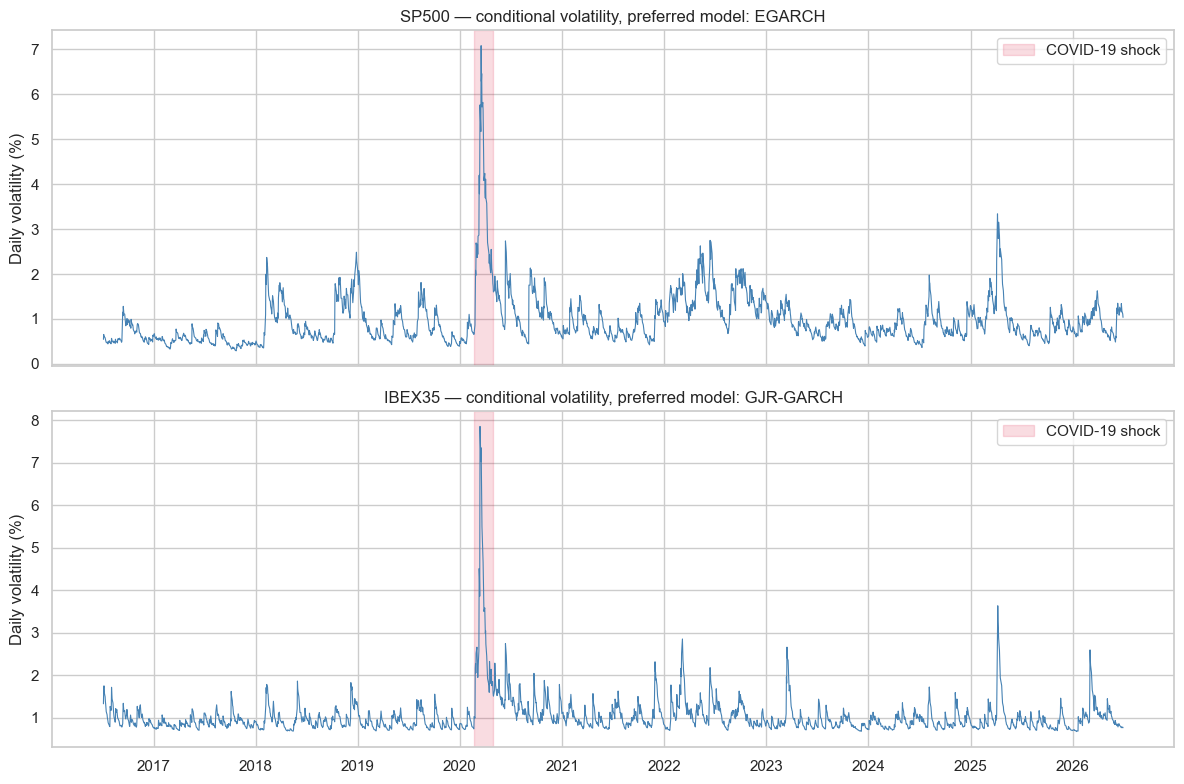

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

covid_start, covid_end = pd.Timestamp("2020-02-20"), pd.Timestamp("2020-04-30")

for ax, idx in zip(axes, returns_pct.columns):
    model = preferred[idx]
    vol = results[(idx, model)].conditional_volatility
    ax.plot(vol.index, vol, linewidth=0.8, color="steelblue")
    ax.axvspan(covid_start, covid_end, color="crimson", alpha=0.15, label="COVID-19 shock")
    ax.set_title(f"{idx} — conditional volatility, preferred model: {model}")
    ax.set_ylabel("Daily volatility (%)")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("")
plt.tight_layout()
plt.show()


**Interpretation.** Both series spend most of the sample in a fairly low,
range-bound volatility regime — mean daily volatility of about **0.97%** for
the S&P 500 and **1.04%** for the IBEX 35 (so the IBEX runs slightly *hotter*
on average, despite the S&P's lower-$\nu$ point estimate from Section 8 —
a gap Section 12 finds is not cleanly established either way) — punctuated
by sharp, short-lived spikes. The COVID-19 window is the standout:
volatility rockets to a sample maximum of **7.08% (S&P 500, 17 March 2020)**
and **7.85% (IBEX 35, 13 March 2020)** — roughly 7-8x the respective
unconditional mean — before decaying back toward baseline over the
following weeks, consistent with the high but sub-unit persistence
estimated in Section 6/7 (a shock this large takes a while to fully
dissipate, but it does dissipate, unlike the near-integrated GARCH result
that ignoring asymmetry produced for the S&P 500).

The IBEX 35's slightly higher COVID peak and higher average volatility
level is a genuine, directly observed cross-market difference. We stop
short, though, of tying it to "a comparatively weaker leverage effect and
thinner residual tails" the way an earlier version of this notebook did:
Section 12 shows the leverage and tail-thickness comparisons across markets
are not both statistically established (leverage: not significant; tails:
suggestive at best, and method-dependent), so they cannot be cited as an
explanation for the volatility-level gap without more evidence than this
notebook currently has. What holds up formally is narrower: the **S&P 500
is genuinely the more persistent of the two markets** (Section 12), while
the **IBEX 35 runs at a higher volatility level** — two separate,
well-supported facts that should not be blended into a single "US
volatility is more reactive and extreme, Spanish volatility just runs
hotter" story without that qualification.

## 11. Summary

1. **All three GARCH-family models fit both indices well**, but asymmetric
   specifications (GJR-GARCH, EGARCH) beat plain GARCH by a wide AIC/BIC
   margin for both — the leverage effect is not optional to model.
2. **Plain GARCH(1,1) overstates persistence for the S&P 500** ($\alpha+\beta
   \approx 0.999$, IGARCH-like) because it has no other way to absorb the
   asymmetric variance response to bad news; allowing $\gamma$ resolves this
   down to a still-high but sub-unit $\approx 0.98$.
3. **The leverage effect is significant in both markets** (GJR and EGARCH
   $\gamma$, p < 0.001 for both indices) — but a formal test (Section 12)
   finds the point-estimate gap between markets (S&P higher) is **not**
   statistically distinguishable from zero, under a $z$-test or a block
   bootstrap. Present and real within each market; not established as
   different across markets.
4. **Fat tails survive GARCH filtering in both markets** (Student-t $\nu
   \approx 5.1$-$5.5$ for S&P 500, $\approx 7.1$-$7.6$ for IBEX 35). The
   S&P 500's point estimate is the fatter-tailed of the two, but Section 12's
   formal test is mixed — not significant by a $z$-test ($p=0.11$),
   significant by a block bootstrap ($p=0.006$) — so we treat this as
   suggestive, not established.
5. **Preferred models — EGARCH (S&P 500), GJR-GARCH (IBEX 35)** — both pass
   the ARCH-LM check on standardized residuals (p = 0.43 and p = 0.93): the
   volatility clustering identified in Stage 1 has been fully absorbed.
6. The **conditional volatility plot** shows a low, range-bound baseline
   punctuated by the COVID-19 shock (peaking at 7.08% for the S&P 500 and
   7.85% for the IBEX 35) with a decay pattern consistent with the
   sub-unit persistence estimates — turbulent, but mean-reverting.
7. **Cross-market comparisons are now formally tested, not just eyeballed**
   (Section 12): persistence is significantly higher for the S&P 500 under
   every measure and method tried ($z$-test and block bootstrap agree);
   leverage and tail-thickness differences are not clearly established
   despite favorable-looking point estimates — leverage is a clean null,
   tails are suggestive but method-dependent.

**Next stage:** use these preferred conditional-volatility models to compute
and backtest Value-at-Risk / Expected Shortfall for both indices.

## 12. Cross-market comparison: formal significance tests

Sections 7 and 8 above, and the "headline questions" section that follows
this one, make categorical claims: the S&P 500's leverage effect is
"stronger," its tails are "heavier." Those claims compare **point
estimates** from two separately-fitted models — GJR $\gamma_{\text{IBEX}}
\approx 0.189$ vs. $\gamma_{\text{S\&P}} \approx 0.233$, for instance — with
no test of whether the gap is distinguishable from sampling noise. The only
argument offered so far is that the ordering repeats across GJR-GARCH and
EGARCH. That is a consistency check, not a hypothesis test, and it is a weak
one specifically: both specifications are fit to the *same* data, so
whatever sampling noise pushed one index's estimate up or down shows up
identically in both. Consistency across specifications tells us the finding
isn't a modelling artifact; it says nothing about whether it's
distinguishable from zero.

We fix that here with a formal test for each of this project's three
headline cross-market claims — leverage ($\gamma$), tail thickness
($\nu$), and persistence ($\alpha+\beta$) — using a standard two-sample
$z$-test on the fitted parameters and their standard errors:

$$
z = \frac{\hat\theta_{\text{S\&P}} - \hat\theta_{\text{IBEX}}}
         {\sqrt{\widehat{\text{SE}}(\hat\theta_{\text{S\&P}})^2 +
                \widehat{\text{SE}}(\hat\theta_{\text{IBEX}})^2}}
$$

treating the two markets' estimates as independent — a simplification we
revisit and stress-test immediately below with a block bootstrap. This
$z$-test also leans on the **asymptotic normality of maximum-likelihood
estimators** (the textbook justification for treating
$\hat\theta \pm \widehat{\text{SE}}(\hat\theta)$ as approximately normal) —
standard, and reliable at this sample size (~2,500 observations per
market), but an assumption rather than a certainty, same as every other
asymptotic test in this project. For the
two multi-parameter comparisons (persistence, defined as $\alpha+\beta$ for
plain GARCH or $\alpha+\beta+\gamma/2$ for GJR-GARCH), the standard error of
the *sum* is **not** the sum of the individual standard errors — it must
come from the full parameter covariance matrix
($\text{Var}(\alpha)+\text{Var}(\beta)+2\,\text{Cov}(\alpha,\beta)$, and the
three-term analog for GJR), available from `arch`'s `param_cov`. Getting
this wrong overstates the standard error substantially (shown explicitly
below) and would bias the test toward *failing* to find significance that
is actually there.

In [13]:
def linear_combo(res, coefs):
    """Point estimate and correct SE of a linear combination of fitted params,
    using the full parameter covariance matrix (not the naive sum of SEs)."""
    est = sum(coefs[k] * res.params[k] for k in coefs)
    cov = res.param_cov
    var = sum(coefs[i] * coefs[j] * cov.loc[i, j] for i in coefs for j in coefs)
    return est, np.sqrt(var)


def z_test(label, est_ibex, se_ibex, est_sp, se_sp):
    diff = est_sp - est_ibex
    se_diff = np.sqrt(se_ibex**2 + se_sp**2)
    z = diff / se_diff
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return {
        "Comparison": label,
        "IBEX 35": est_ibex, "IBEX 35 SE": se_ibex,
        "S&P 500": est_sp, "S&P 500 SE": se_sp,
        "Diff (S&P - IBEX)": diff, "SE(diff)": se_diff,
        "z": z, "p-value": p_value, "Significant (5%)": p_value < 0.05,
    }


gjr_ibex, gjr_sp = results[("IBEX35", "GJR-GARCH")], results[("SP500", "GJR-GARCH")]
egarch_ibex, egarch_sp = results[("IBEX35", "EGARCH")], results[("SP500", "EGARCH")]
garch_ibex, garch_sp = results[("IBEX35", "GARCH")], results[("SP500", "GARCH")]

rows = []

# Leverage: GJR gamma (primary) and EGARCH gamma (cross-check)
rows.append(z_test("Leverage: GJR gamma", gjr_ibex.params["gamma[1]"], gjr_ibex.std_err["gamma[1]"],
                    gjr_sp.params["gamma[1]"], gjr_sp.std_err["gamma[1]"]))
rows.append(z_test("Leverage: EGARCH gamma (cross-check)", egarch_ibex.params["gamma[1]"], egarch_ibex.std_err["gamma[1]"],
                    egarch_sp.params["gamma[1]"], egarch_sp.std_err["gamma[1]"]))

# Tails: nu from each index's own PREFERRED model (Section 9): GJR for IBEX, EGARCH for S&P
rows.append(z_test("Tails: nu (each index's preferred model)", gjr_ibex.params["nu"], gjr_ibex.std_err["nu"],
                    egarch_sp.params["nu"], egarch_sp.std_err["nu"]))

# Persistence: plain GARCH alpha+beta -- the headline "near-unit-root" comparison from Section 3.
# Correct SE uses the full 2x2 covariance submatrix, shown here against the naive (wrong) sum-of-SEs.
persist_ibex, se_persist_ibex = linear_combo(garch_ibex, {"alpha[1]": 1, "beta[1]": 1})
persist_sp, se_persist_sp = linear_combo(garch_sp, {"alpha[1]": 1, "beta[1]": 1})
se_persist_ibex_naive = np.sqrt(garch_ibex.std_err["alpha[1]"]**2 + garch_ibex.std_err["beta[1]"]**2)
se_persist_sp_naive = np.sqrt(garch_sp.std_err["alpha[1]"]**2 + garch_sp.std_err["beta[1]"]**2)
print(f"Persistence SE, correct vs naive (ignoring Cov(alpha,beta)): "
      f"IBEX {se_persist_ibex:.4f} vs {se_persist_ibex_naive:.4f}; "
      f"S&P {se_persist_sp:.4f} vs {se_persist_sp_naive:.4f}")
rows.append(z_test("Persistence: plain GARCH alpha+beta", persist_ibex, se_persist_ibex, persist_sp, se_persist_sp))

# Persistence, asymmetry-corrected: each index's own preferred model's own persistence measure
# (GJR: alpha+beta+gamma/2; EGARCH: beta alone) -- the measure Section 13 actually claims differs.
persist_ibex_gjr, se_persist_ibex_gjr = linear_combo(gjr_ibex, {"alpha[1]": 1, "beta[1]": 1, "gamma[1]": 0.5})
persist_sp_egarch = egarch_sp.params["beta[1]"]
se_persist_sp_egarch = egarch_sp.std_err["beta[1]"]
rows.append(z_test("Persistence: preferred-model measure (GJR a+b+g/2 vs. EGARCH beta)",
                    persist_ibex_gjr, se_persist_ibex_gjr, persist_sp_egarch, se_persist_sp_egarch))

sig_tests_df = pd.DataFrame(rows).set_index("Comparison")
sig_tests_df.round(4)

Persistence SE, correct vs naive (ignoring Cov(alpha,beta)): IBEX 0.0200 vs 0.0445; S&P 0.0104 vs 0.0290


,IBEX 35,IBEX 35 SE,S&P 500,S&P 500 SE,Diff (S&P - IBEX),SE(diff),z,p-value,Significant (5%)
Comparison,,,,,,,,,
Leverage: GJR gamma,0.1890,0.0385,0.2330,0.0400,0.0440,0.0555,0.7929,0.4278,False
Leverage: EGARCH gamma (cross-check),-0.1267,0.0195,-0.1665,0.0166,-0.0398,0.0256,-1.5561,0.1197,False
Tails: nu (each index's preferred model),7.6045,1.1308,5.5277,0.6167,-2.0768,1.2880,-1.6124,0.1069,False
Persistence: plain GARCH alpha+beta,0.9169,0.0200,0.9991,0.0104,0.0822,0.0225,3.6493,0.0003,True
Persistence: preferred-model measure (GJR a+b+g/2 vs. EGARCH beta),0.9150,0.0184,0.9742,0.0057,0.0593,0.0192,3.0837,0.0020,True


**A caveat about the test itself, stated honestly rather than glossed
over.** This $z$-test treats the IBEX 35 and S&P 500 models as
*independent*, since each is fit separately to its own return series. They
are not: the two markets share global risk factors, and their daily returns
are contemporaneously correlated (Stage 1 territory, not re-derived here).
That correlation's effect on the true standard error of the *difference*
could run either way — it is not automatically conservative. We do not
know its sign or size from the z-test alone, so we do not lean on this test
in isolation for the borderline cases below.

**A block bootstrap sidesteps the independence assumption entirely**, by
resampling both return series *jointly* — the same block of calendar days
from both markets together, drawn with replacement — so any contemporaneous
cross-market correlation and any within-market volatility clustering carry
through into the resampled data exactly as they exist in the original
sample. We use a **circular moving-block bootstrap** with 20-trading-day
blocks (long enough to preserve short-run vol clustering, short enough to
generate real variation across replications), refit each of the three
headline comparisons' models on every replication, and read the difference's
significance directly off the empirical distribution of 1,000 bootstrapped
differences. This is computationally heavier than the closed-form
$z$-test — refitting 5 models per replication, ~1,000 replications, a few
minutes of runtime — but it makes no independence assumption at all.

In [14]:
def circular_block_bootstrap_indices(n, block_len, rng):
    n_blocks = int(np.ceil(n / block_len))
    starts = rng.integers(0, n, size=n_blocks)
    idx = np.concatenate([np.arange(s, s + block_len) % n for s in starts])
    return idx[:n]


BLOCK_LEN = 20
N_BOOT = 1_000
BOOT_SEED = 20260716
rng = np.random.default_rng(BOOT_SEED)

n_obs = len(returns_pct)
vals = returns_pct.values
cols = list(returns_pct.columns)
i_ibex, i_sp = cols.index("IBEX35"), cols.index("SP500")

boot_rows, n_fail = [], 0
for b in range(N_BOOT):
    bidx = circular_block_bootstrap_indices(n_obs, BLOCK_LEN, rng)
    boot_vals = vals[bidx]
    ibex_boot = pd.Series(boot_vals[:, i_ibex])
    sp_boot = pd.Series(boot_vals[:, i_sp])
    try:
        b_ibex_gjr = arch_model(ibex_boot, mean="Constant", vol="GARCH", p=1, o=1, q=1, dist="t").fit(disp="off")
        b_sp_gjr = arch_model(sp_boot, mean="Constant", vol="GARCH", p=1, o=1, q=1, dist="t").fit(disp="off")
        b_sp_egarch = arch_model(sp_boot, mean="Constant", vol="EGARCH", p=1, o=1, q=1, dist="t").fit(disp="off")
        b_ibex_garch = arch_model(ibex_boot, mean="Constant", vol="GARCH", p=1, q=1, dist="t").fit(disp="off")
        b_sp_garch = arch_model(sp_boot, mean="Constant", vol="GARCH", p=1, q=1, dist="t").fit(disp="off")
        boot_rows.append({
            "gamma_ibex": b_ibex_gjr.params["gamma[1]"], "gamma_sp": b_sp_gjr.params["gamma[1]"],
            "nu_ibex": b_ibex_gjr.params["nu"], "nu_sp": b_sp_egarch.params["nu"],
            "persist_ibex": b_ibex_garch.params["alpha[1]"] + b_ibex_garch.params["beta[1]"],
            "persist_sp": b_sp_garch.params["alpha[1]"] + b_sp_garch.params["beta[1]"],
        })
    except Exception:
        n_fail += 1

boot_df = pd.DataFrame(boot_rows)
print(f"{len(boot_df)}/{N_BOOT} replications converged ({n_fail} failed and were dropped)")

boot_summary = []
for est_col_ibex, est_col_sp, label in [
    ("gamma_ibex", "gamma_sp", "Leverage: GJR gamma"),
    ("nu_ibex", "nu_sp", "Tails: nu (preferred models)"),
    ("persist_ibex", "persist_sp", "Persistence: plain GARCH alpha+beta"),
]:
    diff = boot_df[est_col_sp] - boot_df[est_col_ibex]
    p_boot = 2 * min((diff <= 0).mean(), (diff >= 0).mean())
    ci_lo, ci_hi = np.percentile(diff, [2.5, 97.5])
    corr = boot_df[est_col_ibex].corr(boot_df[est_col_sp])
    boot_summary.append({
        "Comparison": label, "Bootstrap mean diff": diff.mean(), "Bootstrap SE": diff.std(),
        "95% CI low": ci_lo, "95% CI high": ci_hi,
        "Corr(IBEX est, S&P est)": corr, "Bootstrap p-value": p_boot,
        "Significant (5%)": p_boot < 0.05,
    })

boot_summary_df = pd.DataFrame(boot_summary).set_index("Comparison")
boot_summary_df.round(4)

1000/1000 replications converged (0 failed and were dropped)


,Bootstrap mean diff,Bootstrap SE,95% CI low,95% CI high,"Corr(IBEX est, S&P est)",Bootstrap p-value,Significant (5%)
Comparison,,,,,,,
Leverage: GJR gamma,0.1009,0.0699,-0.0382,0.2375,0.4002,0.150,False
Tails: nu (preferred models),-2.1614,0.9573,-4.4161,-0.6028,0.2524,0.006,True
Persistence: plain GARCH alpha+beta,0.1230,0.0309,0.0673,0.1867,0.2137,0.000,True


**Interpretation. Two of this project's three headline cross-market claims
do not survive formal testing. The third does, and does so under both
methods.**

**Leverage: not statistically significant, under either method.** The GJR
$\gamma$ gap (IBEX 0.189 vs. S&P 0.233) gives $z=0.79$, $p=0.43$; the
EGARCH cross-check gives $z=-1.56$, $p=0.12$. The block bootstrap agrees:
$p=0.15$, with a 95% CI of roughly $[-0.04, 0.24]$ that comfortably
contains zero. Both $\gamma$ estimates are individually **highly
significant within their own market** ($p<0.001$ for both indices, both
specifications — the leverage effect itself is real and not in question).
What is not supported is the comparative claim: with ~2,500 daily
observations per market, the estimation uncertainty on $\gamma$ is too
large, relative to the point-estimate gap, to say the S&P's leverage effect
is *stronger* than the IBEX's. The honest statement is narrower than what
Sections 7 and 13 (below) previously asserted: leverage is present and
significant in both markets, and the point estimates favor the S&P, but
that gap is not distinguishable from sampling noise.

**Tails: the two methods disagree, and that disagreement is itself the
finding worth reporting honestly.** The $z$-test says not significant
($z=-1.61$, $p=0.11$). The block bootstrap says significant
($p=0.006$, 95% CI $[-4.42, -0.60]$, excluding zero). This is not a
contradiction to paper over: the bootstrap's marginal $\nu$ estimates for
the two markets are **positively correlated** across replications
(corr $\approx 0.25$) — exactly the kind of shared-blocks effect the
independence caveat above warned could move the true standard error in
either direction. Positive correlation *shrinks* the standard error of a
*difference*, which is what happens here: the bootstrap SE of the gap
($\approx 0.96$) comes in below the independence-assumed $z$-test SE
($\approx 1.29$), enough to flip the conclusion. The bootstrap's assumption
(no independence imposed) is more defensible than the $z$-test's here, so
if forced to choose we would lean toward the tails difference being real —
but we do not treat this as settled the way persistence is (below): it
rests on a single bootstrap configuration (20-day blocks, 1,000
replications) rather than agreement across methods, and the bootstrap's own
$\nu$ estimates carry a visible finite-sample bias (mean bootstrap $\nu$
runs 1.0-1.2 below the original point estimate for both markets, largely
canceling in the difference but a reason for caution about the bootstrap's
own precision here). **We report this as suggestive but not conclusively
established** — weaker confidence than persistence, but not the clean null
that leverage turned out to be.

**Persistence: statistically significant, under every measure and every
method.** Using plain GARCH's $\alpha+\beta$ (the "near-unit-root" S&P
artifact from Section 3): $z=3.65$, $p=0.0003$. Using each index's own
preferred-model persistence measure (GJR's $\alpha+\beta+\gamma/2$ for the
IBEX, EGARCH's $\beta$ for the S&P — the actual measure the "headline
questions" section below compares): $z=3.08$, $p=0.002$. The block
bootstrap agrees emphatically ($p<0.001$, 95% CI excluding zero by a wide
margin). This is also a good demonstration of why the covariance term
matters: naively summing the individual standard errors instead of using
the full covariance matrix would put the plain-GARCH persistence SEs at
**0.045 (IBEX) and 0.029 (S&P)** instead of the correct **0.020 and
0.010** — more than double, which would have made an genuinely significant
result look considerably weaker than it is. **This is the one cross-market
claim in this notebook that was already correctly asserted, and it now has
a test behind it.**

**What this means for the rest of this notebook.** Sections 7, 8, 11, and
13 (immediately below) state the leverage and tail comparisons
categorically. They are corrected in place, not deleted — the point
estimates and their economic interpretation *within* each market remain,
but the comparative "which market's is stronger/heavier" framing is
replaced with what the evidence actually supports: directionally suggestive
point estimates, not established differences (leverage: null; tails:
suggestive, method-dependent). The persistence comparison is the one
claim that survives fully intact, now with a test to back it.

## 13. Cross-market answers: this project's headline questions

The sections above answer these piecemeal; collected here as direct
answers — now qualified by Section 12's formal significance tests rather
than asserted from point estimates alone.

**Is there a leverage effect in both markets, and which is stronger?** Yes
in both — GJR $\gamma$ is positive and EGARCH $\gamma$ is negative, each
significant at p < 0.001, for both indices. **Which is stronger is not
established.** The point estimates favor the S&P (GJR $\gamma \approx
0.233$ vs. $0.189$; EGARCH $\gamma \approx -0.167$ vs. $-0.127$), and that
ordering repeats across both specifications — but Section 12's formal test
shows this is not distinguishable from sampling noise ($p=0.43$ and
$p=0.12$ respectively), and a block bootstrap that doesn't assume the two
markets are independent agrees ($p=0.15$). With ~2,500 observations per
market, a same-direction point-estimate gap of this size is not enough to
claim one market's asymmetry is genuinely stronger.

**Which market has heavier tails?** Point estimates favor the S&P
(Student-t $\nu \approx 5.1$-$5.5$ vs. $\approx 7.1$-$7.6$ for the IBEX 35),
but **the formal evidence is mixed, not "consistent across specifications"
as an earlier version of this notebook claimed.** A $z$-test on each
market's preferred model does not reach significance ($p=0.11$); a block
bootstrap that doesn't assume the two markets are independent does
($p=0.006$). We report this as suggestive rather than settled (Section 12
discusses why the two methods disagree). What we no longer claim: that this
is "directly in line with" the leverage gap above — that gap is itself not
established, so it cannot corroborate anything.

**How does persistence compare, and does it depend on getting asymmetry
right?** Both are highly persistent, but plain GARCH is misleading for the
S&P 500 specifically: $\alpha+\beta \approx 0.999$, an artifact of forcing a
symmetric model to absorb an asymmetric effect (formally significant:
$z=3.65$, $p=0.0003$ vs. the IBEX's $\approx 0.917$). Once GJR/EGARCH allow
for leverage, S&P persistence settles to $\approx 0.97$-$0.98$ and IBEX to
$\approx 0.92$-$0.93$ — and **this gap is also statistically significant**
($z=3.08$, $p=0.002$), confirmed by both the $z$-test and the block
bootstrap ($p<0.001$). Of this notebook's three headline cross-market
comparisons, persistence is the one that is genuinely, robustly
established: **the S&P 500 is more persistent than the IBEX 35, under
every measure and every method tried.**

**Would a model calibrated on one market transfer to the other?** No, not
without refitting — though the argument for this rests on model *form* and
out-of-sample behavior, not the leverage/tail point estimates above.
AIC/BIC prefer a *different functional form* per index — EGARCH for the
S&P 500, GJR-GARCH for the IBEX 35 (Section 9) — so there isn't a single
"best" specification shared across markets, independent of whether any
individual parameter significantly differs. Stage 5's out-of-sample
backtest makes this concrete rather than theoretical: the same methodology,
applied to each index's *own* calibrated model, validates (in calm periods)
for the S&P 500 and fails for the IBEX 35 (breach clustering) — a finding
about *forecast performance*, not about any single fitted parameter, and
one that doesn't depend on the leverage/tail comparisons above holding up.
The practical conclusion stands: these are two distinct volatility regimes
in the sense that matters for risk management (different preferred
specifications, different out-of-sample validation outcomes, significantly
different persistence) — even though not every individual parameter
comparison clears a formal significance bar.

**Scope note:** this project's limitations (horizon, univariate scope,
distributional assumptions, tail-risk modelling, window length, backtest
refit cadence, transaction costs) are collected in one place at the end of
Stage 5, Section 12 ("Limitations and scope").
